# Fourier transforms

A Fourier transform (FT) is a mathematical transform that decomposes functions depending on space or time into functions depending on spatial frequency or temporal frequency. 


$\hat{f}(\xi) = \int_{-\infty}^{\infty} f(x)\ e^{-i 2\pi \xi x}\,dx,\quad \forall\ \xi \in \mathbb R.$


### Inverse Fourier transform:

$f(x) = \int_{-\infty}^{\infty} \hat f(\xi)\ e^{i 2 \pi \xi x}\,d\xi,\quad \forall\ x \in \mathbb R$

# Discrete Fourier transforms (DFT):

Sometime we don't have analytical functions, but discrete data and we may be interested in characterising the spectral information of such data.

The discrete-time Fourier transform of a discrete sequence of real or complex numbers $x[n]$, for all integers $n$, is a Fourier series, which produces a periodic function of a frequency variable. When the frequency variable, $\omega$, has normalized units of radians/sample, the periodicity is $2\pi$, and the Fourier series is:

To do this, we can carry out a Discrete Fourier Transform (DFT), defined as:

$\chi(k) =\sum_{n=0}^{N-1}x(n)\,e^{\frac{-i\,2\pi\,k\,n}{N}}$

where $k=0, ..., N-1$, where

$N$ = number of samples

$n$ = current sample

$k$ = current frequency, where $𝑘\in[0,N−1]$

$x_n$ = the sine value at sample $n$.

$\chi_k$ = The DFT which includes information of both amplitude and phase.

$\chi_k$ is a complex number that encodes both the amplitude and phase information of a complex sinusoidal component $e^{i\cdot 2\pi kn/N}$ of function $x(n)$.


The amplitude and phase of the signal can be calculated as:

$$A = \frac{|X_k|}{N}= \frac{\sqrt{Re(X_k)^2 + Im(X_k)^2}}{N}$$


$$\phi = atan2(Im(X_k), Re(X_k))$$


where $Im(X_k)$ and $Re(X_k)$ are the imagery and real part of the complex number, $atan2$ is the two-argument form of the $arctan$ function. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

$\chi(k) =\sum_{n=0}^{N-1}x(n)\,e^{\frac{-i\,2\pi\,k\,n}{N}}$

In [2]:
def DFT_function(signal):
    
    N = len(signal)
    n = np.arange(0, N)
    k = n.reshape((N, 1))
    
    exp_term = np.exp(-2j*np.pi*k*n/N)
    
    chi = np.dot(exp_term, signal)
    
    return chi

### Example 1:

Find the DFT of x = (0, 1, 2, 3)

#### Analytical solution:

### Example 3:

The DFT of a sequence $x_n$ of length $N=4$ is defined as:

$$X_k = \sum_{n=0}^{N-1} x_n \, e^{-i \frac{2\pi}{N} kn}, \quad k = 0,1,2,3$$

Here, $x_0=0$, $x_1=1$, $x_2=2$, $x_3=3$.

**First, we compute $X_0$:**

$$\Rightarrow X_0 = \sum_{n=0}^{3} x_n = 0 + 1 + 2 + 3 = 6$$

**Then, $X_1$:**

$$X_1 = \sum_{n=0}^{3} x_n e^{-i \frac{2\pi}{4} n}= \sum_{n=0}^{3} x_n e^{-i \frac{\pi}{2} n}$$

Each term is:

- $n=0$: $0$

- $n=1$: $1 \cdot e^{-i\pi/2} = -i$

- $n=2$: $2 \cdot e^{-i\pi} = -2$

- $n=3$: $3 \cdot e^{-i3\pi/2} = 3i$

$$\Rightarrow X_1 = -i - 2 + 3i = -2 + 2i$$

**Now, for $X_2$:**

$$X_2 = \sum_{n=0}^{3} x_n e^{-i \pi n}$$

- $n=0$: $0$

- $n=1$: $1(-1) = -1$

- $n=2$: $2(1) = 2$

- $n=3$: $3(-1) = -3$

$$\Rightarrow X_2 = -1 + 2 - 3 = -2$$

**Finally, for $X_3$:**

$$X_3 = \sum_{n=0}^{3} x_n e^{-i \frac{3\pi}{2} n}$$

- $n=0$: $0$

- $n=1$: $1 \cdot e^{-i3\pi/2} = i$

- $n=2$: $2 \cdot e^{-i3\pi} = -2$

- $n=3$: $3 \cdot e^{-i9\pi/2} = -3i$

$$X_3 = i - 2 - 3i = -2 - 2i$$

**Final Result:**

$$X = (6,\; -2 + 2i,\; -2,\; -2 - 2i)$$

In [3]:
# Input signal
signal_1 = np.arange(0, 4, 1)

print(signal_1)

[0 1 2 3]


In [4]:
# Calculate the DFT of x(n)
fourier_1 = DFT_function(signal_1)

print(fourier_1[0])
print(fourier_1[1])
print(fourier_1[2])
print(fourier_1[3])

(6+0j)
(-2.0000000000000004+1.9999999999999998j)
(-2-7.34788079488412e-16j)
(-1.9999999999999984-2.000000000000001j)


They match: $X = (6,\; -2 + 2i,\; -2,\; -2 - 2i)$

## DFT using numpy.fft():

https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

https://numpy.org/doc/stable/reference/generated/numpy.fft.fftfreq.html

In [5]:
# FFT of x(n)
fourier_2 = np.fft.fft(signal_1)
print("FFT result:\n",fourier_2)


# Frequencies:
freqs_2 = np.fft.fftfreq(signal_1.size, d=1) # d = 1 in this case, so it is ommitted

print(freqs_2)

FFT result:
 [ 6.+0.j -2.+2.j -2.+0.j -2.-2.j]
[ 0.    0.25 -0.5  -0.25]


## DFT using scipy.fft():

https://docs.scipy.org/doc/scipy/tutorial/fft.html

In [6]:
from scipy import fft

In [7]:
fourier_3 = fft.fft(signal_1)

print(fourier_3)

#frequencies:
freqs_3 = fft.fftfreq(signal_1.size)

print(freqs_3)

[ 6.-0.j -2.+2.j -2.-0.j -2.-2.j]
[ 0.    0.25 -0.5  -0.25]


## Inverse DFT

$x(n)= \frac{1}{N}\sum^{N-1}_{k=0}X_k\,e^{i\,2\pi\,k\,n/N}$



In [8]:
def invDFT_function(any_fourier):
    
    N = len(any_fourier)
    
    n = np.arange(0, N)
    
    k = n.reshape((N, 1))
    
    exp_term = np.exp(2j * np.pi * k * n / N)
    
    x_n = np.dot(exp_term, any_fourier)
    
    return x_n/N

### For our first example:

In [9]:
x_n1 = invDFT_function(fourier_1)

print("x_n =", np.abs(x_n1))

x_n = [5.1191594e-16 1.0000000e+00 2.0000000e+00 3.0000000e+00]


In [10]:
# iFFT With numpy

x_np = np.fft.ifft(fourier_1)

print("x_n =", np.abs(x_np))

x_n = [5.1191594e-16 1.0000000e+00 2.0000000e+00 3.0000000e+00]


### Example 2:

Calculate the DFT of the following series using our own function:

$y(t)=\sum_i^n i\,\cos(i\alpha\,t)$, with $\alpha = 20\pi$

We already know the answer since we computed this using np.fft here:

https://github.com/wbandabarragan/computational-physics-1/blob/main/unit-5/501-Fourier-Analysis.ipynb

In [11]:
def function_series(t, a, n):
    # t - time axis
    # a = 20*pi
    # n is a free parameter, from 0 to n
    
    nu = []
    f = np.zeros(t.size)
    
    for i in range(n+1):
        
        y = i*np.cos(i*a*t)
        
        #Analytical frequencies
        nu.append(i*a/(2*np.pi))
        
        f += y
        
    nu = np.array(nu)    
    return f, nu

### Axes:

In [12]:
# sampling rate
s_rate = 1.e3

# sampling interval
t_s = 1.0/s_rate

# x-axis
t = np.arange(0,np.pi,t_s)

print(t_s, t.size)

# Frequencies and n=5

n = 5
w = 20*np.pi

yy, nu = function_series(t, w, n)

0.001 3142


### Frequencies:

In [13]:
print("frequencies in Hz:", nu[1:])

frequencies in Hz: [10. 20. 30. 40. 50.]


### Signal plot:

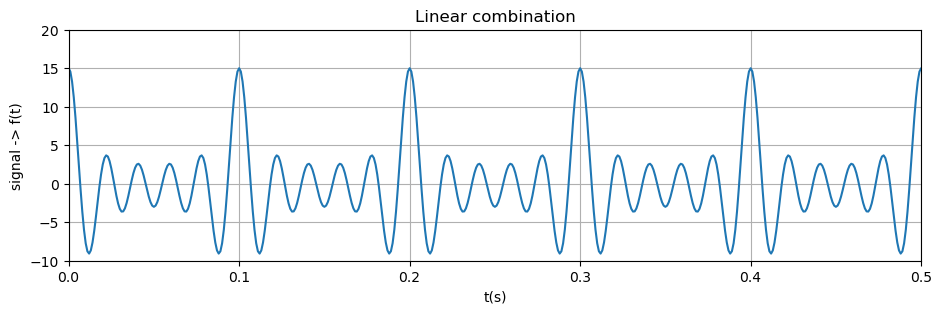

In [14]:
#plotting
axes_range = [0, 0.5, -10, 20]
plt.figure(figsize = (11, 3))

plt.plot(t, yy)

plt.title('Linear combination')

plt.xlabel('t(s)')
plt.ylabel('signal -> f(t)')
plt.axis(axes_range)
plt.grid()
plt.show()

### Fourier transform:

In [15]:
import time

In [16]:
# Numpy implementation with the FFT algorithm: np.fft.fft

start_np = time.time()

X_fourier = np.fft.fft(yy)

end_np = time.time()

print("Elapsed time for numpy: ", end_np - start_np)

Elapsed time for numpy:  0.00047397613525390625


In [17]:
# Fourier transform using our own function with the DFT algorithm
start_dft = time.time()

X_fourier = DFT_function(yy)

end_dft = time.time()

print("Elapsed time for out DFT function: ", end_dft - start_dft)

Elapsed time for out DFT function:  0.1266019344329834


In [18]:
print(X_fourier)

[11.36011332+0.j         11.36573924+1.45047558j 11.38270342+2.90713035j
 ... 11.41126802-4.37626347j 11.38270342-2.90713035j
 11.36573924-1.45047558j]


### Frequencies:

In [19]:
N = len(X_fourier)
print(N)

n = np.arange(N)
print(n)

T = N/s_rate
print(T)

freq = n/T

3142
[   0    1    2 ... 3139 3140 3141]
3.142


### Fourier plot:

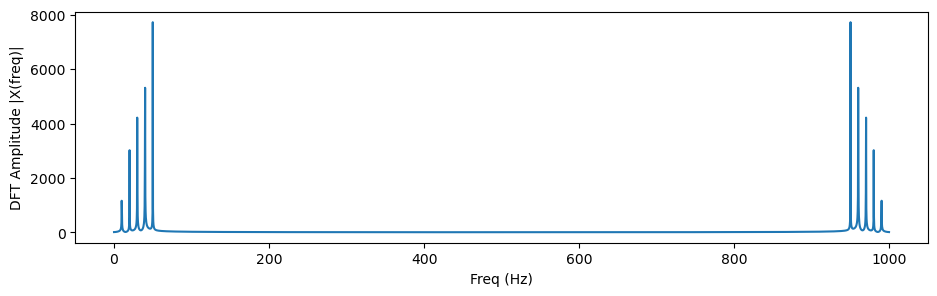

In [20]:
plt.figure(figsize=(11,3))

plt.plot(freq, abs(X_fourier))

plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.show()

### Characteristic frequencies:

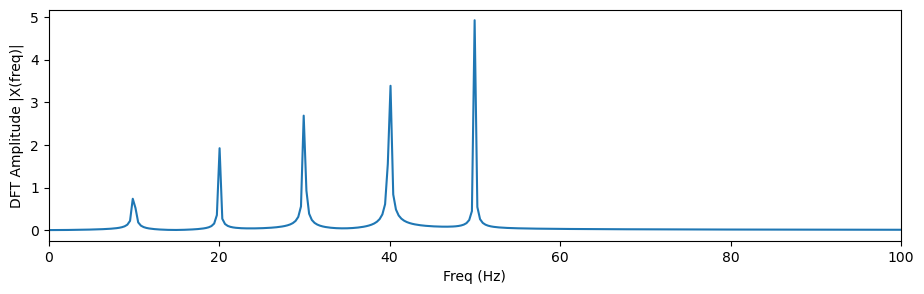

In [21]:
plt.figure(figsize=(11,3))

plt.plot(freq[:N//2], (abs(X_fourier)[:N//2])/(N//2))

plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.xlim(0,100)
plt.show()

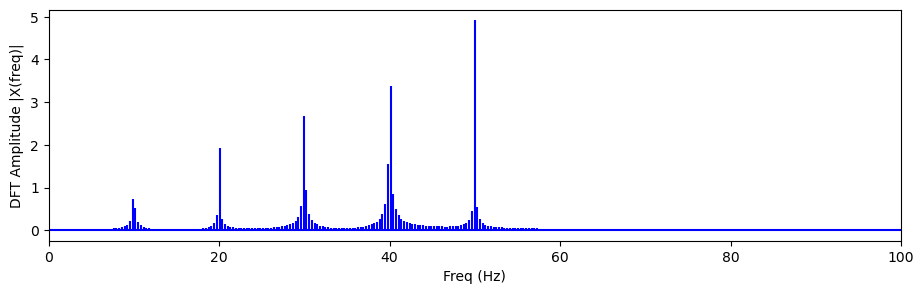

In [22]:
plt.figure(figsize=(11,3))

plt.stem(freq[:N//2], (abs(X_fourier)[:N//2])/(N//2), "b", markerfmt=" ", basefmt="-b")

plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.xlim(0,100)
plt.show()

In [23]:
from scipy.signal import find_peaks

In [24]:
amp_Fm = (abs(X_fourier)[:N//2])/(N//2)

peaks, properties = find_peaks(amp_Fm, height=0)

print(peaks)

[ 31  63  94 126 157]


In [25]:
print("Characteristic frequencies:\n", freq[:N//2][peaks])

Characteristic frequencies:
 [ 9.86632718 20.05092298 29.91725016 40.10184596 49.96817314]


In [26]:
print("Analytical frequencies in Hz:", nu[1:])

Analytical frequencies in Hz: [10. 20. 30. 40. 50.]


### Conclusions:

- Our DFT algorithm/function is correct, consistent with FFT.
  
- The issue is our DFT algorithm is VERY SLOW:

In [27]:
print("Elapsed time for our DFT function: ", end_dft - start_dft)
print("Elapsed time for numpy: ", end_np - start_np)

print("Ratio is: ", (end_dft - start_dft)/(end_np - start_np))

Elapsed time for our DFT function:  0.1266019344329834
Elapsed time for numpy:  0.00047397613525390625
Ratio is:  267.10613682092554
